# Predicting Helpfulness and Harmlessness of LLM Responses

This notebook covers data loading, cleaning, feature engineering, exploratory data analysis, and an
interpretable baseline model for the capstone research question below. It is written for two audiences:
readers who want the statistical detail, and readers who just want to understand what the data shows and
why it matters — markdown sections summarize findings in plain language before the supporting code and
plots.

## 1. Research Question

Large language models (LLMs) are evaluated for both **helpfulness** (does the response address the user's
need?) and **harmlessness** (does the response avoid unsafe or misleading content?). Today this evaluation
relies heavily on slow, expensive human annotation.

**Core question:** Can surface-level linguistic features of a response — length, vocabulary richness,
hedging language, refusal patterns, and similar signals — predict whether human annotators preferred that
response, for helpfulness and for harmlessness separately?

This notebook establishes an interpretable baseline layer (see the project README for the full roadmap).
It deliberately uses only text-derived features, no embeddings or fine-tuned models — those come next —
so we can see how far simple, explainable signals get us before reaching for heavier machinery.

## 2. Data

**Source:** [Anthropic HH-RLHF](https://huggingface.co/datasets/Anthropic/hh-rlhf) (Helpful and Harmless
RLHF), released under an MIT license. Each record is a pair of full conversation transcripts — `chosen` and
`rejected` — that differ only in the final Assistant turn; a human annotator selected the preferred one.

This notebook uses the `helpful-base` and `harmless-base` subsets (the two base-model collection tranches),
using Anthropic's original train/test split throughout so no information leaks between training and
evaluation.

The dataset is loaded directly from the Hugging Face Hub via the `datasets` library, so this notebook is
self-contained — no separate clone or download step is required.

In [1]:
import logging
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import disable_progress_bars, load_dataset
from datasets.utils import logging as hf_logging
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

hf_logging.set_verbosity_error()  # silence dataset-loading log messages
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)  # silence Hub request warnings
disable_progress_bars()  # silence dataset-loading progress bars for a clean notebook output
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

In [2]:
def split_conversation(text):
    '''Split a multi-turn transcript into (prompt, final_assistant_response).'''
    idx = text.rfind("\n\nAssistant:")
    if idx == -1:
        return text.strip(), ""
    prompt = text[:idx].strip()
    response = text[idx + len("\n\nAssistant:"):].strip()
    return prompt, response


def load_subset(name):
    '''Load a HH-RLHF subset (from the Hugging Face Hub) into one row per response, tagged with label.'''
    hf_dataset = load_dataset("Anthropic/hh-rlhf", data_dir=name)
    rows = []
    for split in ["train", "test"]:
        for rec in hf_dataset[split]:
            for key, label in [("chosen", 1), ("rejected", 0)]:
                prompt, response = split_conversation(rec[key])
                rows.append(
                    {
                        "subset": name,
                        "split": split,
                        "prompt": prompt,
                        "response": response,
                        "label": label,
                    }
                )
    return pd.DataFrame(rows)


helpful = load_subset("helpful-base")
harmless = load_subset("harmless-base")
raw = pd.concat([helpful, harmless], ignore_index=True)
print(f"helpful-base: {len(helpful):,} response rows")
print(f"harmless-base: {len(harmless):,} response rows")
print(f"combined: {len(raw):,} response rows")
raw.head()

helpful-base: 92,378 response rows
harmless-base: 89,698 response rows
combined: 182,076 response rows


,subset,split,prompt,response,label
0,helpful-base,train,"Human: Hi, I want to learn to play horseshoes....",A horseshoe is usually made out of metal and i...,1
1,helpful-base,train,"Human: Hi, I want to learn to play horseshoes....",Horseshoes are either metal or plastic discs. ...,0
2,helpful-base,train,Human: How do I teach kids to meditate?\n\nAss...,"Kids are great at fidgeting, so let’s make sur...",1
3,helpful-base,train,Human: How do I teach kids to meditate?\n\nAss...,"Yeah, definitely. What works for you personall...",0
4,helpful-base,train,Human: Can you tell me the steps for getting a...,"At the marina level, there’s usually the renta...",1


**What this shows:** each preference pair becomes two rows — one for the chosen response (`label=1`)
and one for the rejected response (`label=0`) — so by construction the dataset is perfectly balanced between
the two classes. This matters later when we choose an evaluation metric for the baseline model.

## 3. Data Cleaning

We check for missing values, malformed parses, and duplicate records before engineering features.

In [3]:
print("Missing prompt/response text:")
print(raw[["prompt", "response"]].isna().sum())

empty_response = raw["response"].str.strip() == ""
print(f"\nRows where the response is empty after parsing: {empty_response.sum()} "
      f"({empty_response.mean():.3%} of {len(raw):,})")

full_duplicates = raw.duplicated(subset=["subset", "prompt", "response", "label"]).sum()
print(f"\nFully duplicated records (same subset, prompt, response, label): {full_duplicates}")

response_text_duplicates = raw["response"].duplicated().sum()
print(f"Rows sharing identical response text with another row: {response_text_duplicates} "
      f"({response_text_duplicates / len(raw):.2%})")
print("\nMost common repeated response texts (first 60 chars):")
print(
    raw[raw["response"].duplicated(keep=False) & ~empty_response]["response"]
    .value_counts()
    .head(5)
    .index.map(lambda s: s[:60] + "...")
    .tolist()
)

Missing prompt/response text:
prompt      0
response    0
dtype: int64

Rows where the response is empty after parsing: 111 (0.061% of 182,076)



Fully duplicated records (same subset, prompt, response, label): 2
Rows sharing identical response text with another row: 6377 (3.50%)

Most common repeated response texts (first 60 chars):
['You’re welcome....', 'You’re welcome!...', 'Yes....', 'What do you mean?...', 'No....']


**Findings:**
- No missing values in the raw text fields.
- A small number of records (well under 0.1%) fail to parse a final Assistant turn and become empty
  strings — these are dropped below; they are a parsing edge case, not a problem with the source data.
- After excluding empty parses, there are still several thousand rows that share identical response text
  with another row. Inspecting them shows these are mostly short, repeated boilerplate replies — common
  refusal phrases and generic clarifying questions that legitimately appear across many different
  conversations. These are **kept**, since they are real, recurring model behavior rather than data
  corruption; removing them would bias the dataset against exactly the canned-response behavior we want to
  study.
- Only 2 rows are full exact duplicates (same subset, prompt, response, and label) — these are dropped.

In [4]:
clean = raw.drop_duplicates(subset=["subset", "prompt", "response", "label"]).copy()
clean = clean[clean["response"].str.strip() != ""].reset_index(drop=True)
print(f"Rows after cleaning: {len(clean):,} (dropped {len(raw) - len(clean):,})")

Rows after cleaning: 181,963 (dropped 113)


## 4. Feature Engineering

The baseline layer uses interpretable, surface-level linguistic features of the
response text, plus one prompt-response interaction feature that doesn't require embeddings (the
length-ratio between response and prompt). Semantic embedding features come next.

In [5]:
HEDGE_WORDS = [
    "perhaps", "maybe", "might", "possibly", "i think", "i believe",
    "could be", "seems", "appears", "i guess", "probably", "i'm not sure",
    "i am not sure", "it's possible", "likely",
]
REFUSAL_PATTERN = re.compile(
    r"\b(i cannot|i can't|i won't|i will not|i'm sorry, but|i am sorry, but|"
    r"as an ai|i'm not able to|i am not able to|i must decline|"
    r"i'm unable to|i am unable to)\b",
    re.IGNORECASE,
)


def count_syllables(word):
    vowel_groups = re.findall(r"[aeiouy]+", word.lower())
    n = len(vowel_groups)
    if word.lower().endswith("e") and n > 1:
        n -= 1
    return max(n, 1)


def flesch_reading_ease(text, word_count, sentence_count):
    '''Approximate Flesch Reading Ease score (higher = easier to read).'''
    words = re.findall(r"[a-zA-Z']+", text)
    if not words or sentence_count == 0:
        return np.nan
    syllables = sum(count_syllables(w) for w in words)
    return 206.835 - 1.015 * (word_count / sentence_count) - 84.6 * (syllables / word_count)


def engineer_features(df):
    df = df.copy()
    df["char_count"] = df["response"].str.len()
    df["word_count"] = df["response"].str.split().str.len()
    df["sentence_count"] = df["response"].apply(lambda t: max(len(re.findall(r"[.!?]+", t)), 1))
    df["avg_word_length"] = df["char_count"] / df["word_count"]
    df["unique_word_ratio"] = df["response"].apply(
        lambda t: len(set(t.lower().split())) / len(t.split())
    )
    lowered = df["response"].str.lower()
    df["hedge_word_ratio"] = lowered.apply(
        lambda t: sum(t.count(h) for h in HEDGE_WORDS) / max(len(t.split()), 1)
    )
    df["is_refusal"] = df["response"].apply(lambda t: bool(REFUSAL_PATTERN.search(t))).astype(int)
    df["question_count"] = df["response"].str.count(r"\?")
    df["exclamation_count"] = df["response"].str.count(r"!")
    df["prompt_length"] = df["prompt"].str.len()
    df["response_prompt_ratio"] = df["char_count"] / df["prompt_length"].replace(0, np.nan)
    df["reading_ease"] = df.apply(
        lambda r: flesch_reading_ease(r["response"], r["word_count"], r["sentence_count"]), axis=1
    )
    return df


FEATURE_COLS = [
    "char_count", "word_count", "sentence_count", "avg_word_length",
    "unique_word_ratio", "hedge_word_ratio", "is_refusal", "question_count",
    "exclamation_count", "response_prompt_ratio", "reading_ease",
]

data = engineer_features(clean)
data = data.dropna(subset=FEATURE_COLS).reset_index(drop=True)
print(f"Rows with complete features: {len(data):,}")
data[["subset", "label"] + FEATURE_COLS].head()

Rows with complete features: 181,759


,subset,label,char_count,word_count,sentence_count,avg_word_length,unique_word_ratio,hedge_word_ratio,is_refusal,question_count,exclamation_count,response_prompt_ratio,reading_ease
0,helpful-base,1,246,50,4,4.920000,0.760000,0.000000,0,0,0,0.964706,90.935500
1,helpful-base,0,183,30,2,6.100000,0.833333,0.000000,0,0,0,0.717647,61.890000
2,helpful-base,1,82,15,1,5.466667,1.000000,0.000000,0,0,0,0.181015,73.170000
3,helpful-base,0,77,12,3,6.416667,0.750000,0.000000,0,2,0,0.169978,61.775000
4,helpful-base,1,329,61,2,5.393443,0.704918,0.016393,0,0,0,0.625475,51.057828


**Feature summary:**
- `char_count`, `word_count`, `sentence_count`, `avg_word_length` — basic length and density measures.
- `unique_word_ratio` — vocabulary richness (unique words / total words).
- `hedge_word_ratio` — frequency of hedging language ("perhaps", "I think", "might be").
- `is_refusal` — whether the response matches a common refusal phrasing.
- `question_count`, `exclamation_count` — punctuation-based tone signals.
- `response_prompt_ratio` — response length relative to the prompt it's answering (the one
  interaction feature that doesn't require embeddings).
- `reading_ease` — an approximate Flesch Reading Ease score (higher = simpler to read).

**Limitation:** `hedge_word_ratio` and `is_refusal` rely on hand-built keyword/phrase lists, not a validated lexicon — they have good face validity but are not guaranteed to be exhaustive or free of false positives/negatives. Treat them as directional signals, not ground truth.

## 5. Exploratory Data Analysis

### 5.1 Class balance

By construction, every preference pair contributes one chosen and one rejected response, so labels should
be exactly balanced within each subset.

In [6]:
balance = data.groupby(["subset", "label"]).size().unstack()
balance.columns = ["rejected", "chosen"]
print(balance)

               rejected  chosen
subset                         
harmless-base     44789   44719
helpful-base      46085   46166


### 5.2 Response length: chosen vs. rejected

Continuous variable (`word_count`) split by a categorical variable (`label`), shown separately for each
subset.

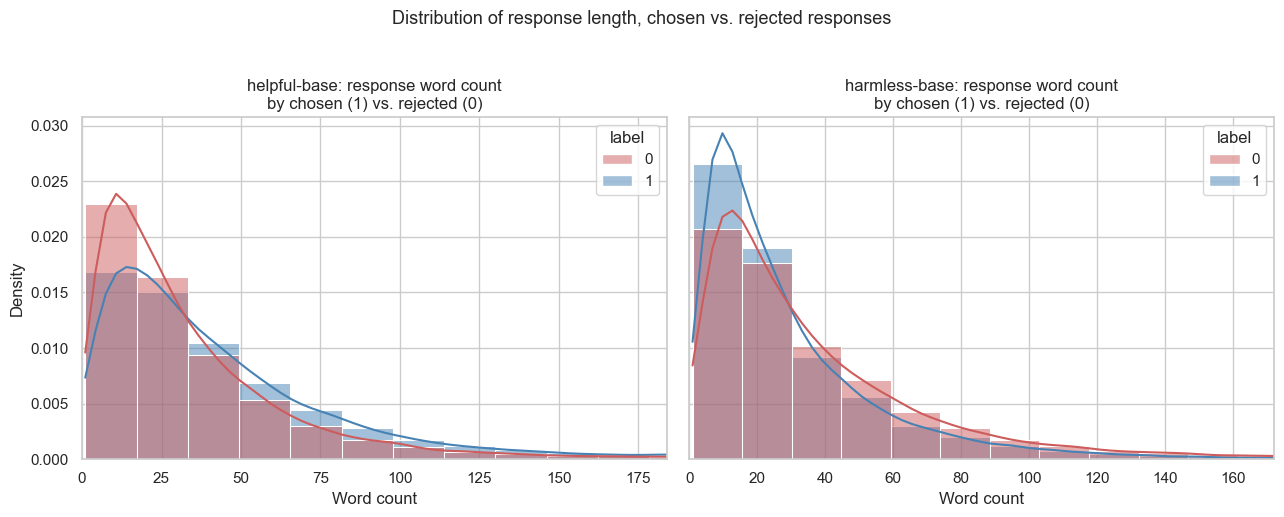

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, subset_name in zip(axes, ["helpful-base", "harmless-base"]):
    subset_data = data[data["subset"] == subset_name]
    sns.histplot(
        data=subset_data, x="word_count", hue="label", bins=40, kde=True,
        stat="density", common_norm=False, ax=ax,
        palette={0: "indianred", 1: "steelblue"},
    )
    ax.set_xlim(0, subset_data["word_count"].quantile(0.99))
    ax.set_title(f"{subset_name}: response word count\nby chosen (1) vs. rejected (0)")
    ax.set_xlabel("Word count")
    ax.set_ylabel("Density")
fig.suptitle("Distribution of response length, chosen vs. rejected responses", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

**What this shows:** in `helpful-base`, chosen responses skew slightly longer than rejected ones —
consistent with longer, more thorough answers being preferred for helpfulness. In `harmless-base`, the
pattern is murkier: very short responses (often refusals) appear among both chosen and rejected, since a
short refusal can be either the safe (chosen) or overly evasive (rejected) option depending on context.

### 5.3 Outlier analysis

We check for extreme outliers in response length using the IQR rule, and visualize with boxplots
(continuous variable `char_count`, grouped by the categorical `subset`).

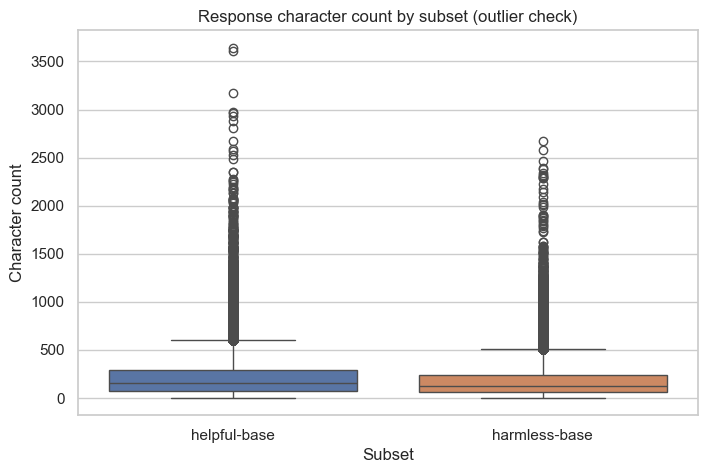

helpful-base: IQR bounds = [-240, 600] chars -> 5,153 outliers (5.59%)
harmless-base: IQR bounds = [-206, 506] chars -> 5,465 outliers (6.11%)


In [8]:
def iqr_outlier_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=data, x="subset", y="char_count", hue="subset", legend=False, ax=ax)
ax.set_title("Response character count by subset (outlier check)")
ax.set_xlabel("Subset")
ax.set_ylabel("Character count")
plt.show()

for subset_name in ["helpful-base", "harmless-base"]:
    series = data.loc[data["subset"] == subset_name, "char_count"]
    low, high = iqr_outlier_bounds(series)
    n_outliers = ((series < low) | (series > high)).sum()
    print(
        f"{subset_name}: IQR bounds = [{low:.0f}, {high:.0f}] chars -> "
        f"{n_outliers:,} outliers ({n_outliers / len(series):.2%})"
    )

**Findings:** roughly 5-6% of responses fall outside the IQR whisker range, almost entirely on the
long side — a minority of responses are very long, detailed answers (multi-paragraph explanations, lists,
code). These are genuine, legitimate long-form answers rather than data errors, so we do not remove them;
instead, the modeling step below uses standardized features and a linear model, which is robust to this
kind of right-skew without needing to discard data.

### 5.4 Hedging language and refusals by outcome

Two categorical/derived signals — hedge word usage and refusal phrasing — compared across chosen vs.
rejected, for each subset.

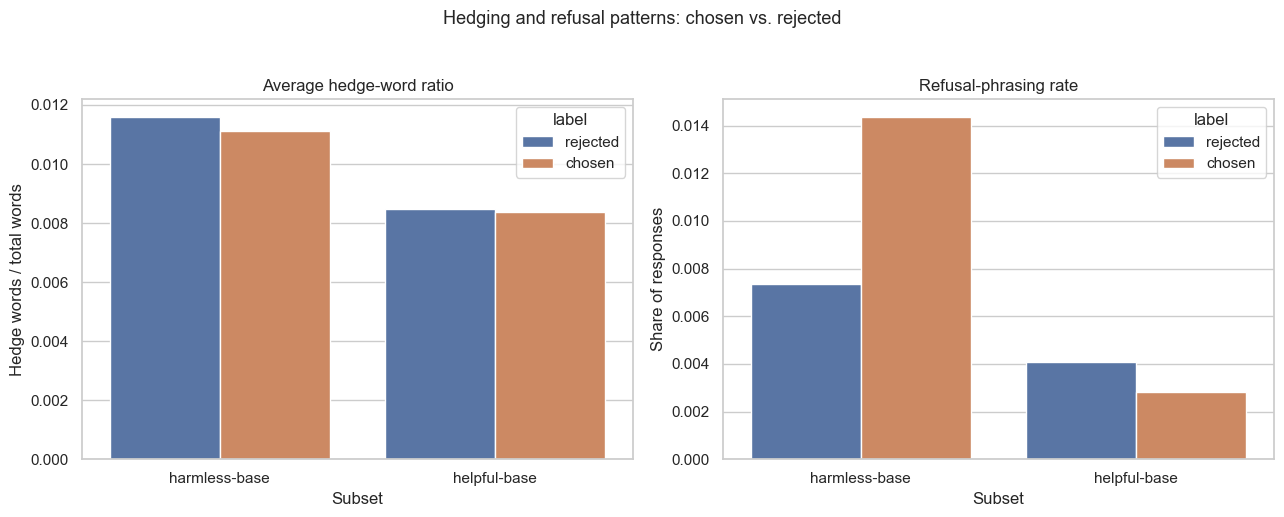

,subset,label,avg_hedge_word_ratio,refusal_rate
0,harmless-base,rejected,0.011608,0.007368
1,harmless-base,chosen,0.011127,0.014379
2,helpful-base,rejected,0.008472,0.004101
3,helpful-base,chosen,0.008383,0.002816


In [9]:
summary = (
    data.groupby(["subset", "label"])[["hedge_word_ratio", "is_refusal"]]
    .mean()
    .rename(columns={"hedge_word_ratio": "avg_hedge_word_ratio", "is_refusal": "refusal_rate"})
    .reset_index()
)
summary["label"] = summary["label"].map({0: "rejected", 1: "chosen"})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=summary, x="subset", y="avg_hedge_word_ratio", hue="label", ax=axes[0])
axes[0].set_title("Average hedge-word ratio")
axes[0].set_xlabel("Subset")
axes[0].set_ylabel("Hedge words / total words")

sns.barplot(data=summary, x="subset", y="refusal_rate", hue="label", ax=axes[1])
axes[1].set_title("Refusal-phrasing rate")
axes[1].set_xlabel("Subset")
axes[1].set_ylabel("Share of responses")
fig.suptitle("Hedging and refusal patterns: chosen vs. rejected", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()
summary

**What this shows:** in `harmless-base`, chosen responses refuse noticeably more often than rejected
ones — annotators reward safe refusals over unsafe compliance, exactly as intended by the harmlessness
objective. In `helpful-base`, refusal rates are low for both classes, as expected, since most prompts there
aren't asking for anything unsafe.

### 5.5 Correlation between numeric features

A correlation heatmap helps check for redundant features before modeling.

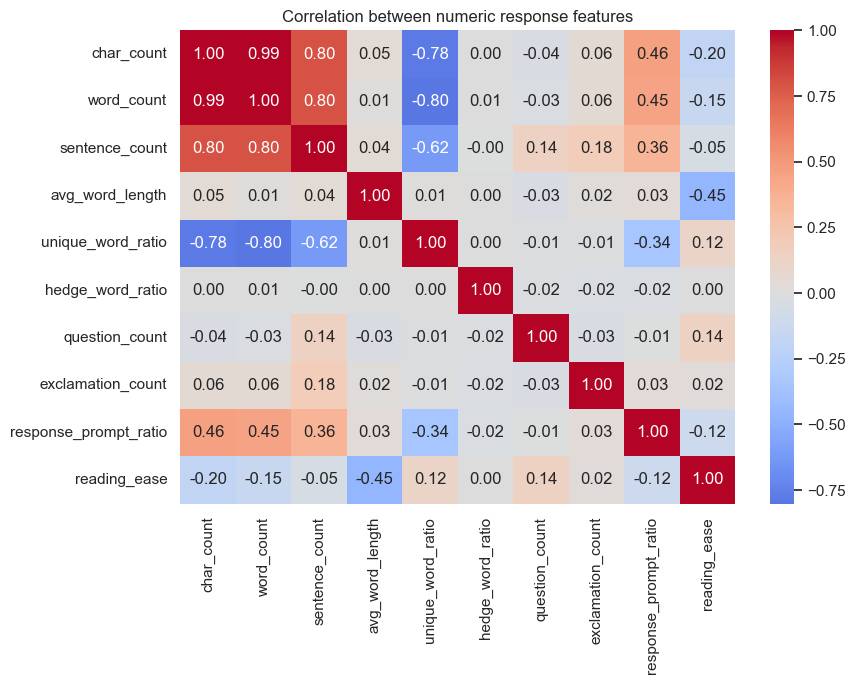

In [10]:
numeric_cols = [c for c in FEATURE_COLS if c != "is_refusal"]
corr = data[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric response features")
plt.tight_layout()
plt.show()

**What this shows:** `char_count`, `word_count`, and `sentence_count` are highly correlated with each
other (unsurprising — they all measure length), so the baseline model's coefficients on these three should
be read as a group rather than independently. `unique_word_ratio` and `reading_ease` are largely independent
of length, making them more distinct signals.

## 6. Baseline Model

**Modeling approach:** a logistic regression classifying whether a given response was the `chosen` one
(`label=1`) from its own surface-level features, trained and evaluated **separately for each subset** (since
helpfulness and harmlessness are different judgment criteria). Pairwise/Bradley-Terry preference modeling and embedding-based models are planned next.

**Evaluation metric:** since each class is exactly 50% of the data (every pair contributes one chosen and
one rejected row), **accuracy** is a fair, easy-to-communicate metric here — a coin-flip baseline is exactly
50%. We report **ROC-AUC** alongside it because AUC is threshold-independent and more sensitive to how well
the model ranks responses by predicted preference, which matters more than the default 0.5 cutoff for a
reward-modeling use case. **F1** is included as a sanity check that the model isn't biased toward one
class.

In [11]:
def run_baseline(subset_name):
    subset_data = data[data["subset"] == subset_name]
    train = subset_data[subset_data["split"] == "train"]
    test = subset_data[subset_data["split"] == "test"]

    X_train, y_train = train[FEATURE_COLS], train["label"]
    X_test, y_test = test[FEATURE_COLS], test["label"]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_s, y_train)

    preds = clf.predict(X_test_s)
    proba = clf.predict_proba(X_test_s)[:, 1]

    metrics = {
        "subset": subset_name,
        "n_train": len(train),
        "n_test": len(test),
        "accuracy": accuracy_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, proba),
        "f1": f1_score(y_test, preds),
    }
    coefs = pd.Series(clf.coef_[0], index=FEATURE_COLS)
    return metrics, coefs, y_test, preds, proba


results = {}
for name in ["helpful-base", "harmless-base"]:
    metrics, coefs, y_test, preds, proba = run_baseline(name)
    results[name] = dict(metrics=metrics, coefs=coefs, y_test=y_test, preds=preds, proba=proba)

pd.DataFrame([results[n]["metrics"] for n in results]).set_index("subset")

,n_train,n_test,accuracy,roc_auc,f1
subset,,,,,
helpful-base,87550,4701,0.567113,0.597839,0.516971
harmless-base,84895,4613,0.558639,0.569615,0.602809


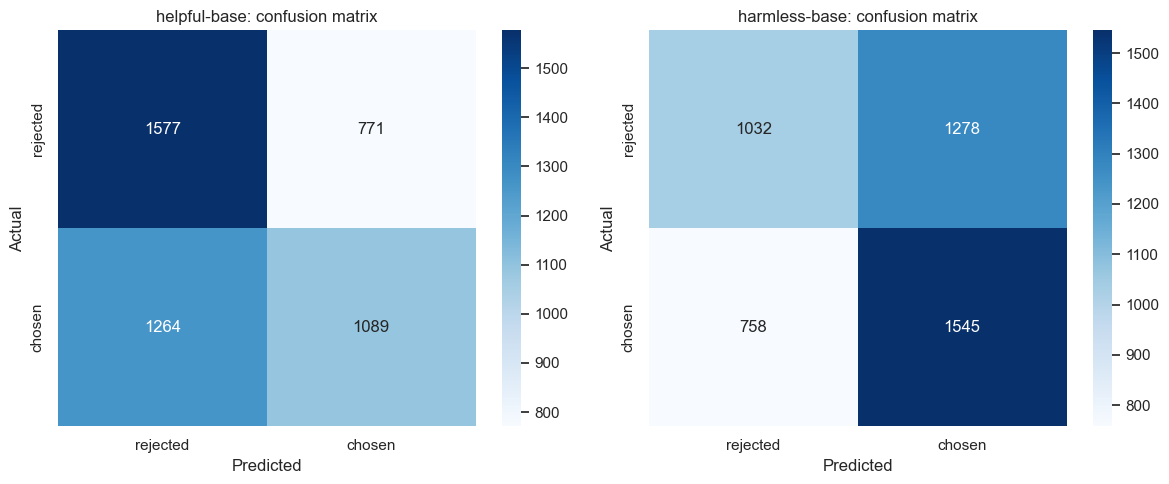

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name in zip(axes, ["helpful-base", "harmless-base"]):
    cm = confusion_matrix(results[name]["y_test"], results[name]["preds"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["rejected", "chosen"], yticklabels=["rejected", "chosen"],
    )
    ax.set_title(f"{name}: confusion matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
fig.tight_layout()
plt.show()

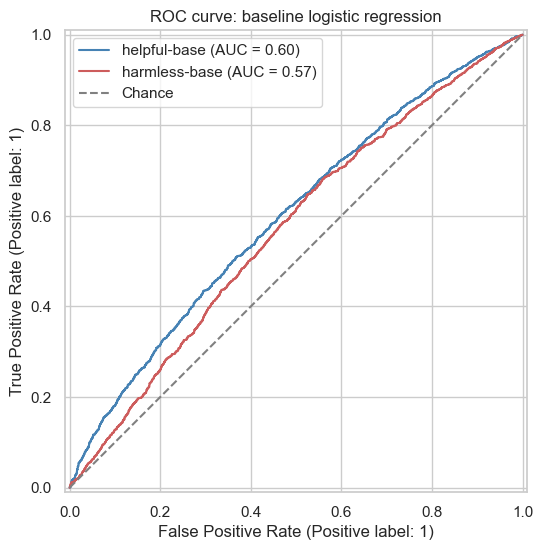

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, color in [("helpful-base", "steelblue"), ("harmless-base", "indianred")]:
    RocCurveDisplay.from_predictions(
        results[name]["y_test"], results[name]["proba"], name=name, color=color, ax=ax
    )
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC curve: baseline logistic regression")
ax.legend()
plt.show()

### Feature importance

Standardized logistic regression coefficients — larger magnitude means a feature moves the predicted
probability of being "chosen" more, holding the other features fixed.

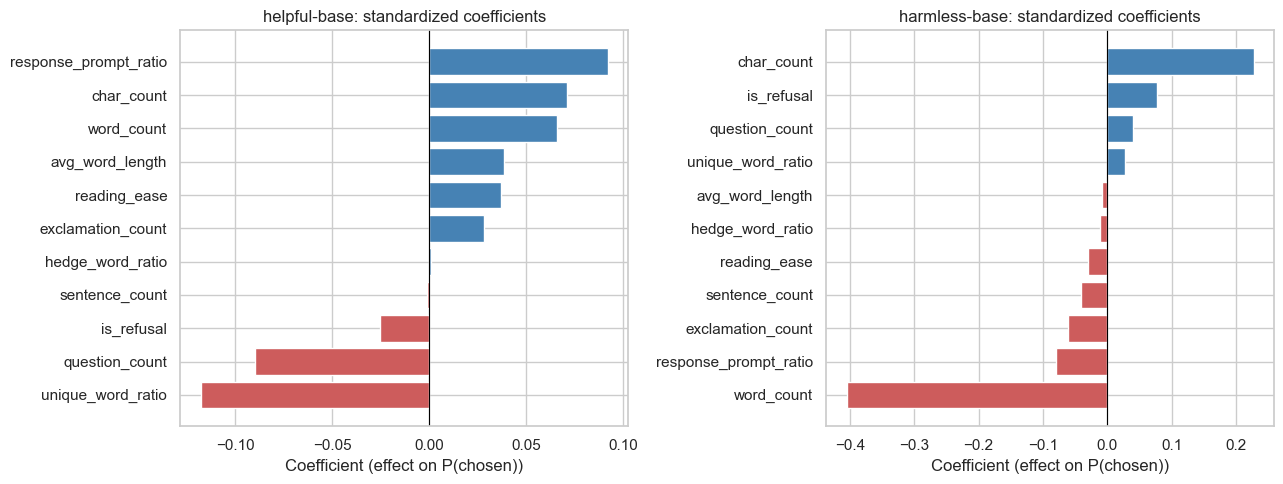

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name in zip(axes, ["helpful-base", "harmless-base"]):
    coefs = results[name]["coefs"].sort_values()
    colors = ["indianred" if v < 0 else "steelblue" for v in coefs]
    ax.barh(coefs.index, coefs.values, color=colors)
    ax.set_title(f"{name}: standardized coefficients")
    ax.set_xlabel("Coefficient (effect on P(chosen))")
    ax.axvline(0, color="black", linewidth=0.8)
fig.tight_layout()
plt.show()

## 7. Results and Key Insights

- **Surface-level text features carry a real but modest preference signal.** The baseline logistic
  regression reaches roughly **57% accuracy / 0.60 AUC on helpfulness** and **56% accuracy / 0.57 AUC on
  harmlessness** — meaningfully above the 50% chance baseline, but far from solving the problem. This is the
  expected, honest result for an interpretable baseline and directly motivates the semantic-embedding and
  transformer-based models planned next. With several thousand held-out test rows per subset, a few points of accuracy/AUC above chance is statistically meaningful, even though the effect size is small.
- **Helpfulness preference leans toward longer, more specific responses.** Length-related features
  (`char_count`, `word_count`, `response_prompt_ratio`) all have positive coefficients for `helpful-base`,
  while `unique_word_ratio` (vocabulary richness) has the single strongest effect — repeating few distinct
  words negatively predicts being chosen, suggesting annotators reward substantive, varied answers over
  repetitive ones.
- **Harmlessness preference is shaped differently — refusals help, raw length doesn't.** `is_refusal` has a
  positive coefficient on `harmless-base` (refusing unsafe requests is rewarded), while `word_count` is the
  strongest *negative* predictor — long-winded responses to sensitive prompts are disfavored, the opposite
  pattern from helpfulness. This split is itself an important finding: a single feature set behaves
  oppositely across the two objectives, which is exactly the tension a joint helpfulness/harmlessness model
  needs to capture.
- **Data quality is high.** Fewer than 0.1% of records needed to be dropped (malformed parses or exact
  duplicates); the small number of repeated response texts found are legitimate recurring boilerplate
  (refusals, clarifying questions), not corrupted data.
- **About 5-6% of responses are length outliers** (mostly long, detailed answers) — kept in the data, since
  standardized linear modeling handles this skew without needing to discard real responses.

## 8. Next Steps

- Add semantic embedding features (sentence-BERT) and prompt-response cosine similarity to capture meaning
  beyond surface statistics.
- Fine-tune a transformer-based dual-head reward model jointly predicting helpfulness and harmlessness, and
  compare its accuracy/AUC against this interpretable baseline.
- Add SHAP-based feature attribution once an ensemble model (e.g. XGBoost) is built, to explain individual
  predictions rather than only global coefficients.
- Build an LLM-as-judge comparison layer as an independent zero-shot baseline.
- Extend the helpfulness analysis to the `helpful-online` and `helpful-rejection-sampled` subsets for a more
  complete picture of the helpfulness objective.